In [16]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

project_root = Path.cwd().resolve()
if project_root.name == 'notebooks':
    project_root = project_root.parent
sys.path.append(str(project_root / 'src'))

from env import *
from agents.train_a2c import train_a2c, A2CConfig
from agents.experiment import Experiment

In [17]:
df_train = pd.read_csv('../data/raw/binance_BTCUSDT_1h_2022-2023.csv')
df_test = pd.read_csv('../data/raw/binance_BTCUSDT_1h_2024.csv')

df_train.head()

,open,high,low,close,volume
0,46216.93,46731.39,46208.37,46656.13,1503.33095
1,46656.14,46949.99,46574.06,46778.14,943.81539
2,46778.14,46928.94,46721.96,46811.77,485.16860
3,46811.77,46916.63,46760.12,46813.20,562.88971
4,46813.21,46887.33,46591.23,46711.05,861.88389


In [18]:
# env_train = MyTradingEnv(df_train, max_steps=2000)
# env_train = SharpeReward(df_train, max_steps=2000)
# env_train = ReturnReward(df_train, max_steps=2000)
env_train = DrawdownAwareReward(df_train, max_steps=2000)

env_train.clear_history()
config = A2CConfig(total_timesteps=200_000)

exp = Experiment("a2c-drawdown")
result = train_a2c(env_train, config, exp)
result['model']



Using cuda device
Logging to /home/twisted/Code/DeepRLTradingResearch/experiments/a2c-drawdown/20260406-193138-480c89


/home/twisted/miniconda3/envs/ml/lib/python3.13/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run A2C on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


------------------------------------
| rollout/              |          |
|    ep_len_mean        | 2e+03    |
|    ep_rew_mean        | -145     |
| time/                 |          |
|    fps                | 277      |
|    iterations         | 100      |
|    time_elapsed       | 46       |
|    total_timesteps    | 12800    |
| train/                |          |
|    entropy_loss       | -1.09    |
|    explained_variance | -9.55    |
|    learning_rate      | 0.0003   |
|    n_updates          | 99       |
|    policy_loss        | -0.0545  |
|    value_loss         | 0.00575  |
------------------------------------
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 2e+03    |
|    ep_rew_mean        | -178     |
| time/                 |          |
|    fps                | 280      |
|    iterations         | 200      |
|    time_elapsed       | 91       |
|    total_timesteps    | 25600    |
| train/                |          |
|

In [19]:
import seaborn as sns

sns.set_theme(style='whitegrid')

train_steps = env_train.get_steps_df()
train_steps.head()

,episode,step,df_index,action,reward,terminated,truncated,portfolio_value,cash,position,units,entry_price,position_value,holding_time,current_price,n_trades,last_exit_reason,unrealized_pnl
0,1,1,7280,0,0.000000e+00,False,False,1000.0,1000.0,0,0.000000,0.00,0.0,0,20487.76,0,NaN,0.0
1,1,2,7281,0,0.000000e+00,False,False,1000.0,1000.0,0,0.000000,0.00,0.0,0,20714.01,0,NaN,0.0
2,1,3,7282,0,0.000000e+00,False,False,1000.0,1000.0,0,0.000000,0.00,0.0,0,20750.56,0,NaN,0.0
3,1,4,7283,0,0.000000e+00,False,False,1000.0,1000.0,0,0.000000,0.00,0.0,0,20730.54,0,NaN,0.0
4,1,5,7284,1,1.136868e-16,False,False,1000.0,0.0,1,0.048313,20698.27,1000.0,0,20698.27,0,NaN,0.0


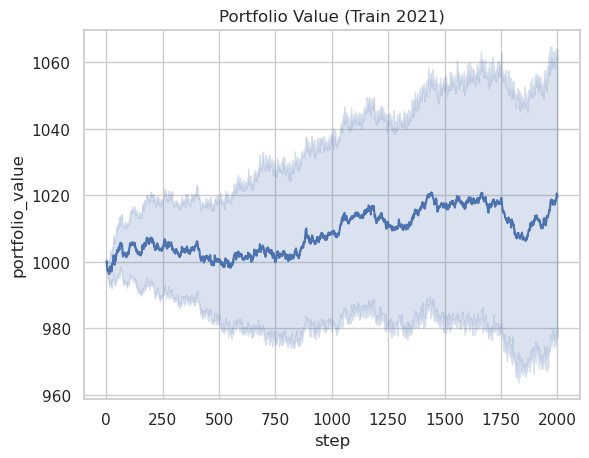

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')

sns.lineplot(data=train_steps, x='step', y='portfolio_value')
plt.title('Portfolio Value (Train 2021)')
plt.show()
